LAB 8: VARIATIONAL AUTOENCODER (VAE)

------------------------------------------------------------
Loading and Preparing Data
------------------------------------------------------------
Dataset: Handwritten Digits (8x8 images)
Training samples: 1437
Test samples: 360
Input shape: (64,)

------------------------------------------------------------
Building VAE Model
------------------------------------------------------------

Encoder Summary:


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_dense_1     │ (None, 256)       │     16,640 │ encoder_input[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 256)       │          0 │ encoder_dense_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_dense_2     │ (None, 128)       │     32,896 │ dropout_4[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 128)       │          0 │ encoder_dense_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        258 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        258 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_1          │ (None, 2)         │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 50,052 (195.52 KB)

 Trainable params: 50,052 (195.52 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ latent_input (InputLayer)       │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_1 (Dense)         │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_2 (Dense)         │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Dense)          │ (None, 64)             │        16,448 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,856 (194.75 KB)

 Trainable params: 49,856 (194.75 KB)

 Non-trainable params: 0 (0.00 B)


------------------------------------------------------------
Training VAE
------------------------------------------------------------
Training completed!
Final training loss: 24.7169
Final validation loss: 24.5820

------------------------------------------------------------
Latent Space Analysis
------------------------------------------------------------
Training latent space shape: (1437, 2)
Test latent space shape: (360, 2)

Generating images from latent space...

GENERATING VISUALIZATIONS


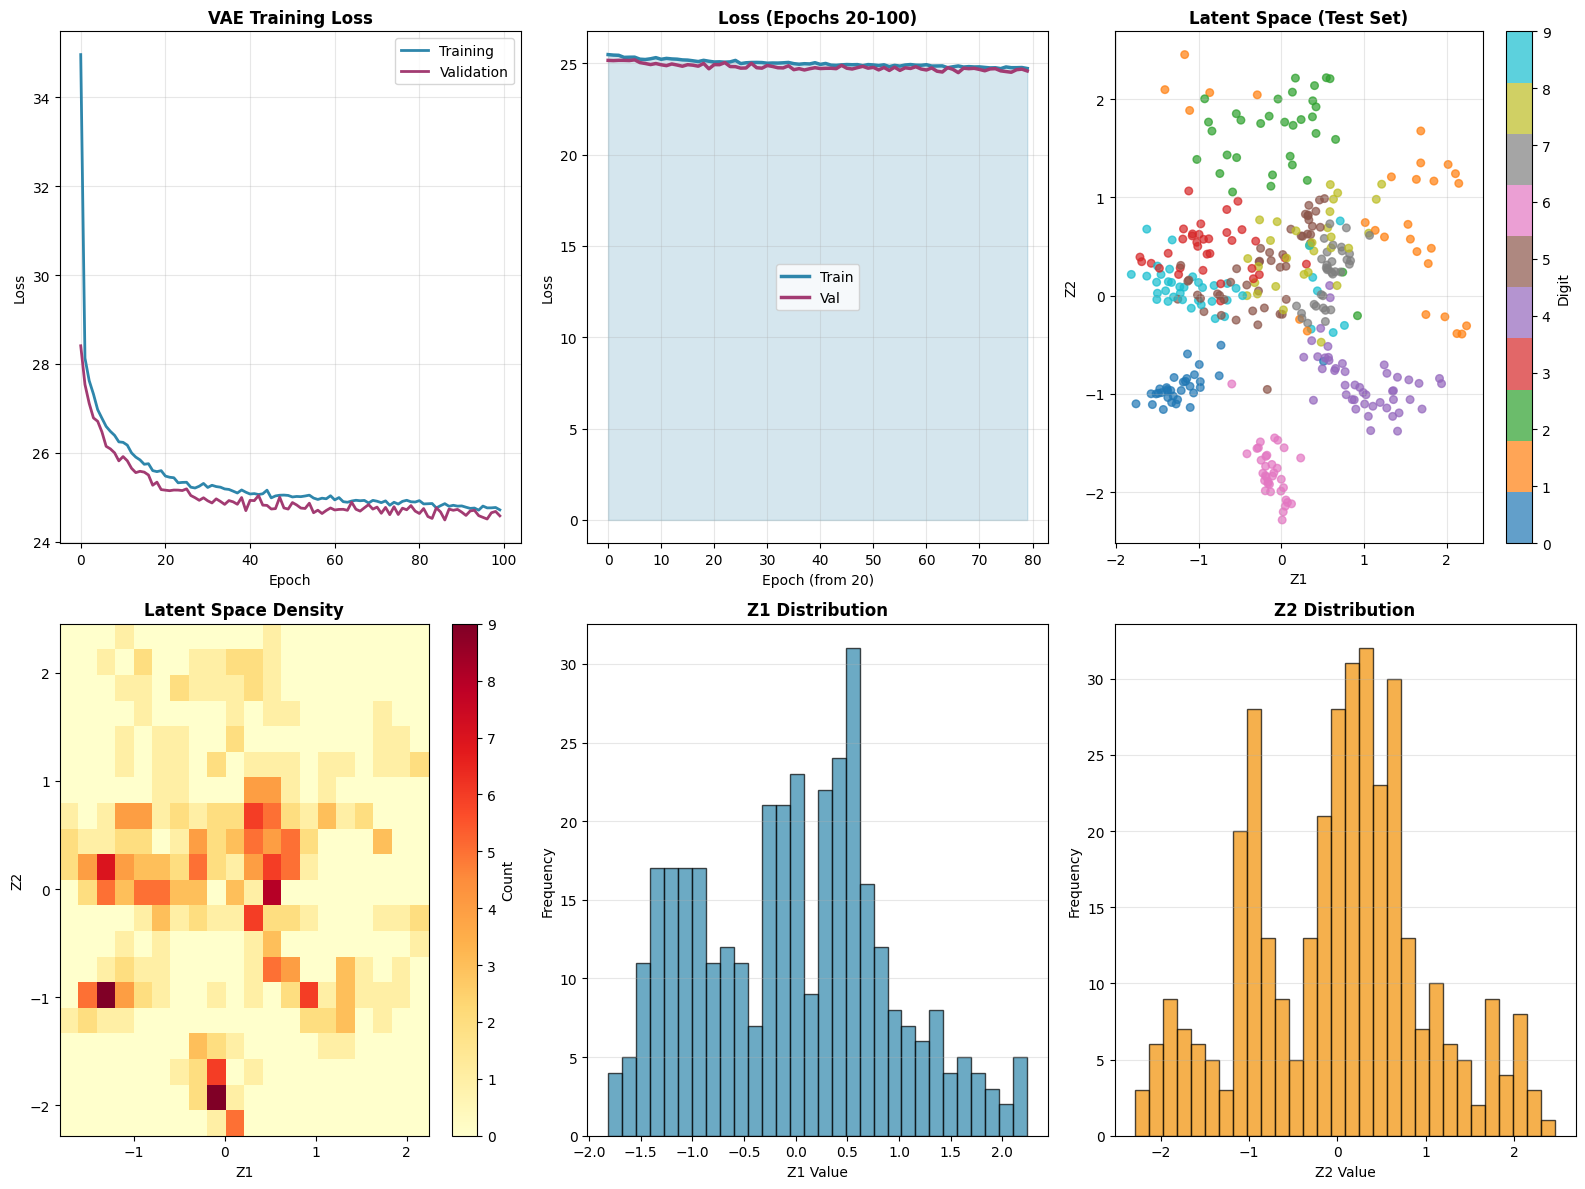


Generating reconstruction examples...


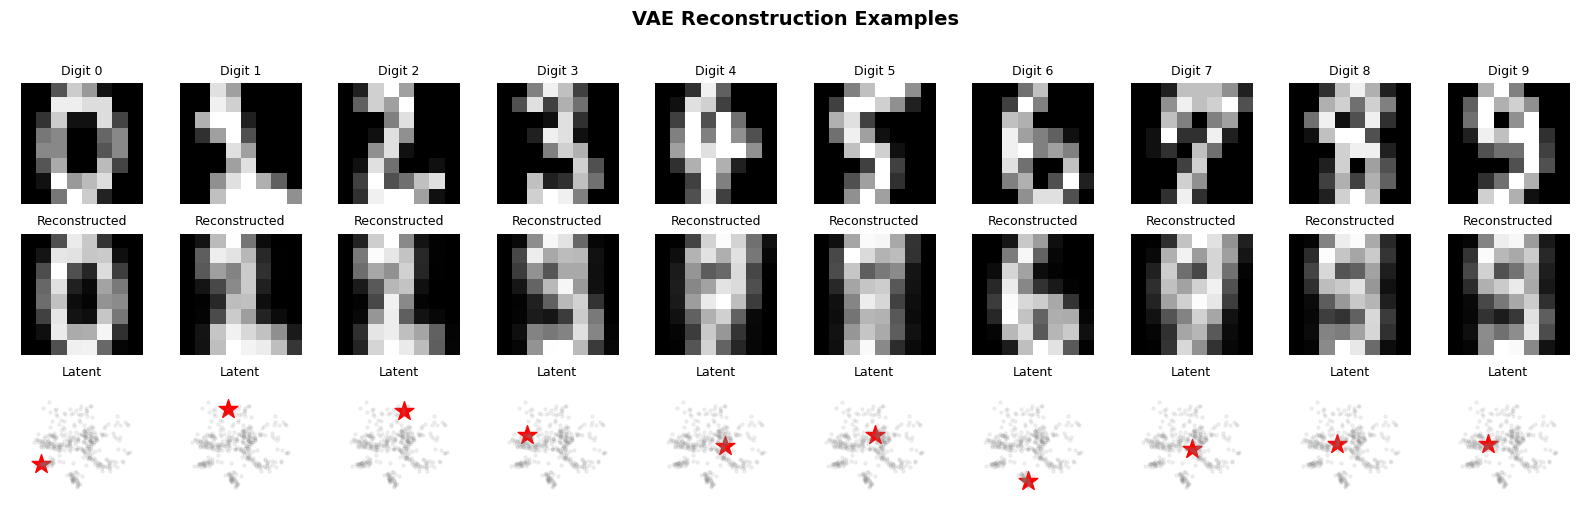


Generating latent space interpolation...
Interpolating between digit 8 and digit 5


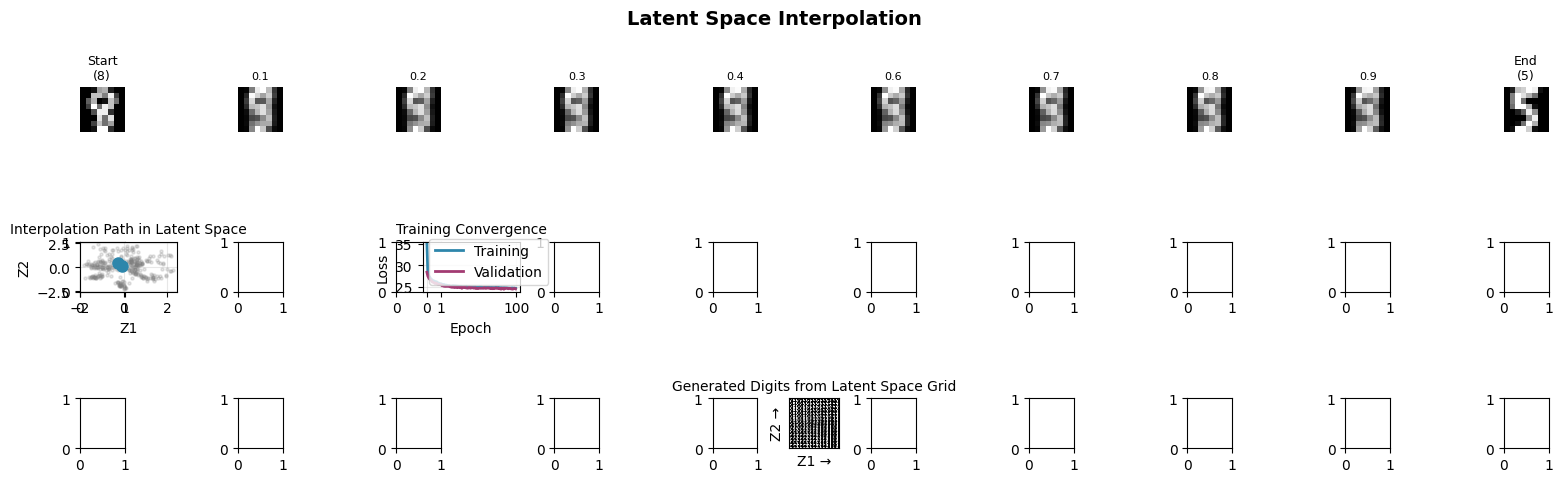


LAB 8 COMPLETED SUCCESSFULLY

SUMMARY STATISTICS
VAE Model Configuration:
  - Input dimension: 64
  - Latent dimension: 2
  - Encoder layers: 2 Dense + Sampling
  - Decoder layers: 2 Dense

Training Results:
  - Final training loss: 24.716896
  - Final validation loss: 24.581991
  - Total epochs: 100

Latent Space Statistics:
  - Z1 range: [-1.81, 2.24]
  - Z2 range: [-2.28, 2.45]
  - Z1 mean: -0.0318, std: 0.9241
  - Z2 mean: -0.0081, std: 0.9944


In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns

print("=" * 60)
print("LAB 8: VARIATIONAL AUTOENCODER (VAE)")
print("=" * 60)

# ===== LOAD AND PREPARE DATA =====
print("\n" + "-" * 60)
print("Loading and Preparing Data")
print("-" * 60)

# Load digits dataset
digits = load_digits()
X = digits.data.astype('float32')
y = digits.target

# Normalize to [0, 1]
X = X / 16.0

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Dataset: Handwritten Digits (8x8 images)")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Input shape: {X_train[0].shape}")

# ===== VAE MODEL =====
print("\n" + "-" * 60)
print("Building VAE Model")
print("-" * 60)

# Hyperparameters
latent_dim = 2  # 2D latent space for visualization
input_dim = X_train.shape[1]

# Sampling layer
class Sampling(layers.Layer):
    """Reparameterization trick"""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# Encoder Input
encoder_inputs = keras.Input(shape=(input_dim,), name="encoder_input")
x = layers.Dense(256, activation="relu", name="encoder_dense_1")(encoder_inputs)
x = layers.Dropout(0.2)(x)
x = layers.Dense(128, activation="relu", name="encoder_dense_2")(x)
x = layers.Dropout(0.2)(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])

encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
print("\nEncoder Summary:")
encoder.summary()

# Decoder Input
latent_inputs = keras.Input(shape=(latent_dim,), name="latent_input")
x = layers.Dense(128, activation="relu", name="decoder_dense_1")(latent_inputs)
x = layers.Dropout(0.2)(x)
x = layers.Dense(256, activation="relu", name="decoder_dense_2")(x)
x = layers.Dropout(0.2)(x)
decoder_outputs = layers.Dense(input_dim, activation="sigmoid", name="decoder_output")(x)

decoder = Model(latent_inputs, decoder_outputs, name="decoder")
print("\nDecoder Summary:")
decoder.summary()

# Build complete VAE
class VAELoss(layers.Layer):
    def call(self, inputs):
        original, reconstruction, z_mean, z_log_var = inputs
        # Reconstruction loss
        reconstruction_loss = keras.losses.binary_crossentropy(original, reconstruction)
        reconstruction_loss *= input_dim
        reconstruction_loss = tf.reduce_mean(reconstruction_loss)

        # KL loss
        kl_loss = 1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1)) * -0.5

        total_loss = reconstruction_loss + kl_loss
        self.add_loss(total_loss)

        return reconstruction

def build_vae(encoder, decoder):
    inputs = keras.Input(shape=(input_dim,), name="input")
    z_mean, z_log_var, z = encoder(inputs)
    reconstruction = decoder(z)

    # Apply loss layer
    outputs = VAELoss()([inputs, reconstruction, z_mean, z_log_var])

    vae_model = Model(inputs, outputs, name="vae")
    return vae_model

vae = build_vae(encoder, decoder)
vae.compile(optimizer=Adam(learning_rate=1e-3))

print("\n" + "-" * 60)
print("Training VAE")
print("-" * 60)

history = vae.fit(
    X_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, X_test),
    verbose=0
)

print("Training completed!")
print(f"Final training loss: {history.history['loss'][-1]:.4f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.4f}")

# ===== LATENT SPACE EXPLORATION =====
print("\n" + "-" * 60)
print("Latent Space Analysis")
print("-" * 60)

# Get latent representations
z_mean_train, _, _ = encoder.predict(X_train, verbose=0)
z_mean_test, _, _ = encoder.predict(X_test, verbose=0)

print(f"Training latent space shape: {z_mean_train.shape}")
print(f"Test latent space shape: {z_mean_test.shape}")

# Generate images from latent space
print("\nGenerating images from latent space...")

# Create a grid of latent variable values
n = 15
x_min, x_max = z_mean_test[:, 0].min() - 1, z_mean_test[:, 0].max() + 1
y_min, y_max = z_mean_test[:, 1].min() - 1, z_mean_test[:, 1].max() + 1

xx = np.linspace(x_min, x_max, n)
yy = np.linspace(y_min, y_max, n)

# Generate grid of images
grid_size = 8  # 8x8 pixel images
grid_images = np.zeros((n * grid_size, n * grid_size))

for i, yi in enumerate(yy):
    for j, xi in enumerate(xx):
        z_sample = np.array([[xi, yi]])
        x_decoded = decoder.predict(z_sample, verbose=0)
        digit = x_decoded[0].reshape(8, 8)
        grid_images[i * grid_size:(i + 1) * grid_size,
                    j * grid_size:(j + 1) * grid_size] = digit

# ===== VISUALIZATIONS =====
print("\n" + "=" * 60)
print("GENERATING VISUALIZATIONS")
print("=" * 60)

fig = plt.figure(figsize=(16, 12))

# 1. Training Loss
ax1 = plt.subplot(2, 3, 1)
ax1.plot(history.history['loss'], label='Training', linewidth=2, color='#2E86AB')
ax1.plot(history.history['val_loss'], label='Validation', linewidth=2, color='#A23B72')
ax1.set_title('VAE Training Loss', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Loss Zoom
ax2 = plt.subplot(2, 3, 2)
ax2.plot(history.history['loss'][20:], linewidth=2.5, color='#2E86AB', label='Train')
ax2.plot(history.history['val_loss'][20:], linewidth=2.5, color='#A23B72', label='Val')
ax2.fill_between(range(len(history.history['loss'][20:])),
                 history.history['loss'][20:], alpha=0.2, color='#2E86AB')
ax2.set_title('Loss (Epochs 20-100)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch (from 20)')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Latent Space Scatter
ax3 = plt.subplot(2, 3, 3)
scatter = ax3.scatter(z_mean_test[:, 0], z_mean_test[:, 1], c=y_test, cmap='tab10', s=30, alpha=0.7)
ax3.set_title('Latent Space (Test Set)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Z1')
ax3.set_ylabel('Z2')
plt.colorbar(scatter, ax=ax3, label='Digit')
ax3.grid(True, alpha=0.3)

# 4. Latent Space Density
ax4 = plt.subplot(2, 3, 4)
density = ax4.hist2d(z_mean_test[:, 0], z_mean_test[:, 1], bins=20, cmap='YlOrRd')
ax4.set_title('Latent Space Density', fontsize=12, fontweight='bold')
ax4.set_xlabel('Z1')
ax4.set_ylabel('Z2')
plt.colorbar(density[3], ax=ax4, label='Count')

# 5. Latent Distribution Z1
ax5 = plt.subplot(2, 3, 5)
ax5.hist(z_mean_test[:, 0], bins=30, color='#2E86AB', alpha=0.7, edgecolor='black')
ax5.set_title('Z1 Distribution', fontsize=12, fontweight='bold')
ax5.set_xlabel('Z1 Value')
ax5.set_ylabel('Frequency')
ax5.grid(True, alpha=0.3, axis='y')

# 6. Latent Distribution Z2
ax6 = plt.subplot(2, 3, 6)
ax6.hist(z_mean_test[:, 1], bins=30, color='#F18F01', alpha=0.7, edgecolor='black')
ax6.set_title('Z2 Distribution', fontsize=12, fontweight='bold')
ax6.set_xlabel('Z2 Value')
ax6.set_ylabel('Frequency')
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ===== RECONSTRUCTION EXAMPLES =====
print("\nGenerating reconstruction examples...")

fig, axes = plt.subplots(3, 10, figsize=(16, 5))

# Show original, latent mean, and reconstructed for different digits
sample_indices = []
for digit in range(10):
    idx = np.where(y_test == digit)[0][0]
    sample_indices.append(idx)

for col, idx in enumerate(sample_indices):
    # Original
    axes[0, col].imshow(X_test[idx].reshape(8, 8), cmap='gray')
    axes[0, col].set_title(f'Digit {y_test[idx]}', fontsize=9)
    axes[0, col].axis('off')

    # Get latent representation
    z_mean_sample, _, _ = encoder.predict(X_test[idx:idx+1], verbose=0)

    # Reconstructed
    X_reconstructed = decoder.predict(z_mean_sample, verbose=0)
    axes[1, col].imshow(X_reconstructed[0].reshape(8, 8), cmap='gray')
    axes[1, col].set_title(f'Reconstructed', fontsize=9)
    axes[1, col].axis('off')

    # Latent point
    axes[2, col].scatter(z_mean_sample[0, 0], z_mean_sample[0, 1], s=200, color='red', marker='*')
    axes[2, col].scatter(z_mean_test[:, 0], z_mean_test[:, 1], s=5, alpha=0.1, color='gray')
    axes[2, col].set_xlim(z_mean_test[:, 0].min() - 1, z_mean_test[:, 0].max() + 1)
    axes[2, col].set_ylim(z_mean_test[:, 1].min() - 1, z_mean_test[:, 1].max() + 1)
    axes[2, col].set_title(f'Latent', fontsize=9)
    axes[2, col].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Reconstructed', fontsize=11, fontweight='bold')
axes[2, 0].set_ylabel('Latent Position', fontsize=11, fontweight='bold')

plt.suptitle('VAE Reconstruction Examples', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ===== LATENT INTERPOLATION =====
print("\nGenerating latent space interpolation...")

fig, axes = plt.subplots(3, 10, figsize=(16, 5))

# Pick two random digits
idx1 = np.random.randint(0, len(X_test))
idx2 = np.random.randint(0, len(X_test))

z1, _, _ = encoder.predict(X_test[idx1:idx1+1], verbose=0)
z2, _, _ = encoder.predict(X_test[idx2:idx2+1], verbose=0)

print(f"Interpolating between digit {y_test[idx1]} and digit {y_test[idx2]}")

# Show starting digit
axes[0, 0].imshow(X_test[idx1].reshape(8, 8), cmap='gray')
axes[0, 0].set_title(f'Start\n({y_test[idx1]})', fontsize=9)
axes[0, 0].axis('off')

# Interpolate
for i in range(1, 9):
    alpha = i / 9.0
    z_interp = (1 - alpha) * z1 + alpha * z2

    # Reconstruction from interpolated z
    x_interp = decoder.predict(z_interp, verbose=0)

    axes[0, i].imshow(x_interp[0].reshape(8, 8), cmap='gray')
    axes[0, i].set_title(f'{alpha:.1f}', fontsize=8)
    axes[0, i].axis('off')

# Show ending digit
axes[0, 9].imshow(X_test[idx2].reshape(8, 8), cmap='gray')
axes[0, 9].set_title(f'End\n({y_test[idx2]})', fontsize=9)
axes[0, 9].axis('off')

# Latent space path
ax_path = plt.subplot(3, 5, 6)
ax_path.plot([z1[0, 0], z2[0, 0]], [z1[0, 1], z2[0, 1]], 'o-', linewidth=2, markersize=8, color='#2E86AB')
ax_path.scatter(z_mean_test[:, 0], z_mean_test[:, 1], s=5, alpha=0.2, color='gray')
ax_path.set_title('Interpolation Path in Latent Space', fontsize=10)
ax_path.set_xlabel('Z1')
ax_path.set_ylabel('Z2')
ax_path.grid(True, alpha=0.3)

# Loss curve
ax_loss = plt.subplot(3, 5, 7)
ax_loss.plot(history.history['loss'], label='Training', linewidth=2, color='#2E86AB')
ax_loss.plot(history.history['val_loss'], label='Validation', linewidth=2, color='#A23B72')
ax_loss.set_title('Training Convergence', fontsize=10)
ax_loss.set_xlabel('Epoch')
ax_loss.set_ylabel('Loss')
ax_loss.legend()
ax_loss.grid(True, alpha=0.3)

# Generated grid
ax_grid = plt.subplot(3, 1, 3)
ax_grid.imshow(grid_images, cmap='gray', interpolation='nearest')
ax_grid.set_title('Generated Digits from Latent Space Grid', fontsize=10)
ax_grid.set_xlabel('Z1 →')
ax_grid.set_ylabel('Z2 →')
ax_grid.set_xticks([])
ax_grid.set_yticks([])

plt.suptitle('Latent Space Interpolation', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("LAB 8 COMPLETED SUCCESSFULLY")
print("=" * 60)

# Summary statistics
print("\n" + "=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)
print(f"VAE Model Configuration:")
print(f"  - Input dimension: {input_dim}")
print(f"  - Latent dimension: {latent_dim}")
print(f"  - Encoder layers: 2 Dense + Sampling")
print(f"  - Decoder layers: 2 Dense")
print(f"\nTraining Results:")
print(f"  - Final training loss: {history.history['loss'][-1]:.6f}")
print(f"  - Final validation loss: {history.history['val_loss'][-1]:.6f}")
print(f"  - Total epochs: {len(history.history['loss'])}")
print(f"\nLatent Space Statistics:")
print(f"  - Z1 range: [{z_mean_test[:, 0].min():.2f}, {z_mean_test[:, 0].max():.2f}]")
print(f"  - Z2 range: [{z_mean_test[:, 1].min():.2f}, {z_mean_test[:, 1].max():.2f}]")
print(f"  - Z1 mean: {z_mean_test[:, 0].mean():.4f}, std: {z_mean_test[:, 0].std():.4f}")
print(f"  - Z2 mean: {z_mean_test[:, 1].mean():.4f}, std: {z_mean_test[:, 1].std():.4f}")